In [10]:
import vr1
from vr1.core import FuelAssembly, Lattice
from vr1.settings import VR1Settings
from vr1.writer import WriterOpenMC
from vr1.plots import test_plots
from vr1.materials import VR1Materials
from vr1.VR1facility import Facility
import vr1.lattice_units as vlu
import openmc
from vr1.core import core_designs
import vr1.utils
openmc.Materials.cross_sections = "/Users/macris/openmc_data/endfb-viii.0-hdf5/cross_sections.xml" #must use viii.0 for C12


# VR1 Disaster Exercise

The purpose of this notebook is to test some examples of extreme conditions and how they would affect the reactor system. 


In [11]:
vr1_materials = VR1Materials()
mats = vr1_materials.get_materials()
mats.export_to_xml()

 Your settings are initialized for you. Reproduce your lattice from the last notebook where indicated and generate the appropriate openmc.Geometry object. 

In [15]:
import os
keffs = []
# rod_heights = [0,10,20,30,40,50,60,70,80,84.7]

R1_height = 0
E1_height = 0
R2_height = 0

batches = 40

vr1_materials = VR1Materials()
mats = vr1_materials.get_materials()
mats.export_to_xml()


lattice_input =   [['w'  ,'w','w'    ,'w','w'  ,'w','w'  ,'w'],
                    ['w'  ,'w','v56'  ,'w','v25','w','w'  ,'w'],
                    ['w'  ,'w','6'    ,'8',f'6_{R1_height}'  ,'8','w'  ,'w'],
                    ['w'  ,'w','d'    ,'O','8'  ,f'6_{E1_height}','w'  ,'w'],
                    ['v56','w','v12_6','8','O'  ,'8','v30','w'],
                    ['w'  ,'w','v12_d','O','d'  ,'8','w'  ,'w'],
                    ['w'  ,'w','6'    ,'8',f'6_{R2_height}','8'  ,'w'  ,'w'],
                    ['w'  ,'w','w'    ,'w','w','w'  ,'w'  ,'w']]

lattice_obj = Lattice(materials=vr1_materials,lattice_str=lattice_input)

for i in [0,7]:
    for j in range(0,8):
        code = lattice_input[i][j]
        lattice_units = vlu.LatticeUnitVR1(materials=vr1_materials)
        lattice_units.load()
        lattice_unit = lattice_units.get(code)
        # print(type(lattice_unit),type(mats),type(vr1_materials.air))
        vr1.utils.replace_water_fill(lattice_unit, vr1_materials, vr1_materials.air)

        lattice_obj.lattice.universes[i][j] = lattice_unit

facility_obj = Facility(materials=vr1_materials)



vr1_model = facility_obj.build(lattice=lattice_obj)

geometry = openmc.Geometry(root=vr1_model)
geometry.export_to_xml()

settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
settings.temperature = {'method':'interpolation','range':(293.15,923.15)} #unsure
settings.batches = batches
settings.inactive = 15 
settings.particles = 10000
settings.photon_transport = True
source_area = openmc.stats.Box(lattice_obj.source_lower_left,lattice_obj.source_upper_right)
settings.source_rejection_fraction = 0.01
settings.source = openmc.IndependentSource(space=source_area, constraints={'fissionable': True})
settings.export_to_xml()

openmc.run()

with openmc.StatePoint(f'statepoint.{batches}.h5') as sp:
    k_eff = sp.keff.nominal_value
    keffs.append(k_eff)



import matplotlib.pyplot as plt


/Users/macris/miniforge3/envs/vr1-env/lib/python3.11/site-packages/openmc/source.py:668: FutureWarning: This class is deprecated in favor of 'IndependentSource'
  warnings.warn(


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

KeyboardInterrupt: 

Text(0.5, 0.98, 'k-eff vs control rod height')

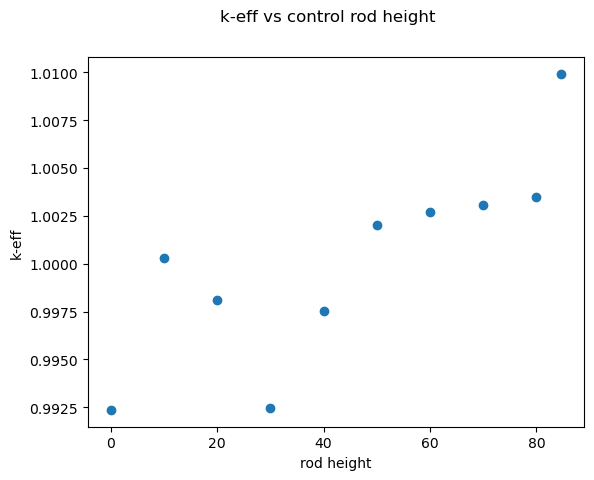

In [4]:
# errors = [0.00153,0.00186,0.00152,0.00161,0.00224,0.00215,0.00157,0.00141,0.00183,0.00119]
plt.scatter(rod_heights,keffs)#,yerr=errors)
plt.xlabel('rod height')
plt.ylabel('k-eff')
plt.suptitle('k-eff vs control rod height')

## Getting keff from a Run

As you have seen, calling *openmc.run()* prints out the keff. But extracting it that way is primative. To obtain all sorts of information, including keff, from a run in OpenMC, a file called a "statepoint" is generated for you. It is typically named "statepoint.{#_of_batches}.h5". You can get keff from it as by simply loading the statepoint file and calling the *keff* method on it, as shown below. The method *nominal_value* is used to convert it to a float you can plot.

In [7]:
print(lattice_obj.source_upper_right)

(28.6, 28.6, 66.4025)


In [5]:
sp = openmc.StatePoint('./statepoint.30.h5')
keff_variable = sp.keff
keff = sp.keff.nominal_value
print(keff)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = './statepoint.30.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

# Exercise: Rod Worth of R1

Run the your core configuration for 10 different rod heights of the R1 rod and plot keff against the height. The heights you should use are 0, 10, 20, ..., 80, 84.7 (<- fully removed).

In [ ]:
# code here

In [ ]:
# code here

In [ ]:
keffs_manual = [0.93705, 0.94087,0.94832, 0.93441, 0.94014] #30
keffs_manual = [ 0.93784, 0.93804, 0.94430, ] #50